In [ ]:
import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants import *
from utils import *

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc

import numpyro
from numpyro_model import numpyro_model

In [4]:
@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned = model(params_halo_pot, params_disk_rho, dict_data)

    frac_err = 0.1 

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vr_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vphi_data_binned'] - vphi_binned)**2) / (frac_err * dict_data['vphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vz_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavr_data_binned'] - sigmavr_binned)**2) / (frac_err * dict_data['sigmavr_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavphi_data_binned'] - sigmavphi_binned)**2) / (frac_err * dict_data['sigmavphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavz_data_binned'] - sigmavz_binned)**2) / (frac_err * dict_data['sigmavz_data_binned'] + 1e-3) )

    return -0.5 * log_likelihood

@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 2. #Gyr
    n_steps = 1000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(dict_data['w0'], acc_fn, n_steps, dt, initial_time, unroll)
    density_model = jax.vmap(histogram3d)(xv[:, :, :3], None)

    A = density_model.reshape(len(xv), -1).T.astype(jnp.float32)/n_steps
    y = dict_data['density_data'].reshape(-1).astype(jnp.float32)
    sig = jnp.sqrt(y + 1.0).astype(jnp.float32)  # Poisson noise + 1.0 floor

    weights = solve_lbfgs_softplus(A, y, sig, l2=1e-3, maxiter=300)

    weights_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), jnp.repeat(weights, n_steps).ravel())

    r_model    = jnp.linalg.norm(xv[:, :, :2], axis=-1)
    vr_model   = (xv[:, :, 0] * xv[:, :, 3] + xv[:, :, 1] * xv[:, :, 4]) / r_model
    vr_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vr2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavr_binned = jnp.sqrt(jnp.clip(vr2_binned - vr_binned**2, a_min=0.0))

    vphi = -(-xv[:, :, 1] * xv[:, :, 3] + xv[:, :, 0] * xv[:, :, 4]) / r_model
    vphi_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vphi2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavphi_binned = jnp.sqrt(jnp.clip(vphi2_binned - vphi_binned**2, a_min=0.0))

    vz_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vz2_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavz_binned = jnp.sqrt(jnp.clip(vz2_binned - vz_binned**2, a_min=0.0))

    return vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned

@jax.jit
def _nll_z(z, A, y, sig, l2):
    x = jnn.softplus(z)  # strictly positive
    r = (A @ x - y) / sig
    return 0.5 * jnp.dot(r, r) + 0.5 * l2 * jnp.dot(x, x)
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A, y, sigma, l2=1e-3, maxiter=200, tol=1e-6):
    z0 = jnp.zeros(A.shape[1], A.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol)
    res = solver.run(z0, A, y, sigma, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat

In [5]:
#Hyperparameters for dynesty
ndim = 5
nlive = 500
n_particles = 10_000
PATH_DATA = f'/data/hz420-2/'

save_file = PATH_DATA + f'/Schwarzschild/trail_sample.pkl'
save_sampler = PATH_DATA + f'/Schwarzschild/trail_sample_idata.nc'

with open('./IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('./axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}

def log_prior(params):
    logp = 0.0
    for key in params.keys():
        scale = prior_scales[key]
        logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
    return logp


parameters = {
    'logM_halo': numpyro.distributions.Normal(
        loc=prior_loc['logM_halo'],
        scale=prior_scales['logM_halo']
    ),
    'logRs_halo': numpyro.distributions.Normal(
        loc=prior_loc['logRs_halo'],
        scale=prior_scales['logRs_halo'],
    ),
    'logM_disk': numpyro.distributions.Normal(
        loc=prior_loc['logM_disk'],
        scale=prior_scales['logM_disk'],
    ),
    'logRs_disk': numpyro.distributions.Normal(
        loc=prior_loc['logRs_disk'],
        scale=prior_scales['logRs_disk'],
    ),
    'logHs_disk': numpyro.distributions.Normal(
        loc=prior_loc['logHs_disk'],
        scale=prior_scales['logHs_disk'],
    ),
}

init_from_minimiser = True

n_warmup = 200
n_samples = 400
num_chains = 2
max_tree_depth = 6
target_accept_prob = 0.8
step_size = 1e-2
adapt_step_size = True
extra_fields = ('num_steps', 'adapt_state.step_size')
jit_model_args = True

if init_from_minimiser:

    # file_name = path+f'radial_migration_kernel/mock_sample/L_conditioned/minimization_result_withMHgrad_{Nknots}knots4_binned.npy'#_L@10
    # file_name = read_file
    # minimiser_results = np.load(file_name)
    init_guess = ground_truth
    print('Initial guess from minimiser:', init_guess)
    init_strategy=numpyro.infer.initialization.init_to_value(values=init_guess)
else:
    init_strategy=numpyro.infer.init_to_sample()



print('model initialising...')

hmc_model = numpyro_model(logl, parameters, dict_data,
                      expand_args=False, log_prior_fn=log_prior)#logL_numpyro, logL_zero

print('model initialised, and start running MCMC...')
hmc_model.run_mcmc(num_warmup=n_warmup, num_samples=n_samples, num_chains=num_chains,
                   init_strategy=init_strategy, max_tree_depth=max_tree_depth, step_size=step_size,
                   target_accept_prob=target_accept_prob, adapt_step_size=adapt_step_size,
                   chain_method="vectorized", extra_fields=extra_fields, jit_model_args=jit_model_args) # sequential, vectorized

print('MCMC finished, collecting samples...')
samples = hmc_model.samples()
print(samples)
# file = path+f'radial_migration_kernel/mock_sample/L_conditioned/Prior_distribution_{Nknots}knots.pkl'
file = save_file
with open(file,'wb') as f:
    pickle.dump(samples, f)

ef = hmc_model.mcmc.get_extra_fields(group_by_chain=True,
                                )
num_steps = ef['num_steps']    # shape (n_chains, n_warmup+n_samples)
print("Avg leapfrog steps per sample:",
      num_steps.mean())
print("Total lnL/grad calls ≃", num_steps.sum())

hmc_model.mcmc.print_summary()

import arviz as az


# 2) convert to an ArviZ InferenceData
idata = az.from_numpyro(posterior=model.mcmc, num_chains=num_chains)

# 3) write to NetCDF on disk
idata.to_netcdf(save_sampler)

Initial guess from minimiser: {'logM_halo': 11.90308952331543, 'logRs_halo': 1.2916462421417236, 'logM_disk': 9.0, 'logRs_disk': 0.4771212339401245, 'logHs_disk': -0.22184871137142181}
model initialising...
model initialised, and start running MCMC...


XlaRuntimeError: FAILED_PRECONDITION: Buffer Definition Event: Error dispatching computation: Error dispatching computation: Error preparing computation: Out of memory allocating 153468884352 bytes.

In [2]:
with open('./axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

In [19]:

positions, grid_min, grid_max, n_bins = np.array([0,0,0]), np.array([0, 0, 0]), np.array([60.0, 25.0, 15.0]), jnp.array([30, 15, 15])

normalized = (positions - grid_min) / (grid_max - grid_min)

# Convert to bin indices
bin_coords = jnp.floor(normalized * n_bins).astype(jnp.int32)
print(bin_coords)
# Clip to valid range [0, n_bins-1]
bin_coords = jnp.clip(bin_coords, 0, n_bins - 1)

# Flatten to 1D index: idx = i + j*nx + k*nx*ny
strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(n_bins[:-1])])
bin_indices = jnp.sum(bin_coords * strides, axis=-1)



In [5]:
@jax.jit
def assign_regular_grid(positions, grid_min, grid_max, n_bins, strides):
    """
    Assign positions to regular grid cells.
    
    Parameters
    ----------
    positions : array (N, D) - particle positions
    grid_min : array (D,) - minimum bounds for each dimension
    grid_max : array (D,) - maximum bounds for each dimension
    n_bins : array (D,) - number of bins in each dimension (int)
    
    Returns
    -------
    bin_indices : array (N,) - flattened bin index for each particle
    """
    # Normalize to [0, 1]
    normalized = (positions - grid_min) / (grid_max - grid_min)
    jax.debug.print("normalized: {normalized}", normalized=normalized)

    
    # Convert to bin indices
    bin_coords = jnp.floor(normalized * n_bins).astype(jnp.int32)
    
    # Clip to valid range [0, n_bins-1]
    bin_coords = jnp.clip(bin_coords, 0, n_bins - 1)
    
    # Flatten to 1D index: idx = i + j*nx + k*nx*ny
    bin_indices = jnp.sum(bin_coords * strides, axis=-1)

    # Check if any normalized coordinate is >= 1.0 for each particle
    out_of_bounds = jnp.any((normalized >= 1.0) | (normalized < 0.0), axis=-1)
    return jnp.where(out_of_bounds, n_bins.prod(), bin_indices)

@jax.jit
def assign_regular_grid1d(positions, grid_min, grid_max, n_bins):
    """
    Assign positions to regular grid cells.
    
    Parameters
    ----------
    positions : array (N) - particle positions
    grid_min : float - minimum bounds for each dimension
    grid_max : float - maximum bounds for each dimension
    n_bins : int - number of bins in each dimension
    
    Returns
    -------
    bin_indices : array (N,) - flattened bin index for each particle
    """

    dx = (grid_max - grid_min)/n_bins
    index = (positions - grid_min) // dx

    out_of_bounds = (index >= n_bins) | (index < 0.0)
    return jnp.where(out_of_bounds, n_bins, index).astype(jnp.int32)

# @jax.jit
# def assign_regular_grid(positions, grid_min, grid_max, n_bins):
#     """
#     Assign positions to regular grid cells.
    
#     Parameters
#     ----------
#     positions : array (N, D) - particle positions
#     grid_min : array (D,) - minimum bounds for each dimension
#     grid_max : array (D,) - maximum bounds for each dimension
#     n_bins : array (D,) - number of bins in each dimension (int)
    
#     Returns
#     -------
#     bin_indices : array (N,) - flattened bin index for each particle
#     """
#     # Normalize to [0, 1]
#     dx = (grid_max - grid_min)/n_bins
#     normalized = (positions - grid_min) // dx
    
#     # Convert to bin indices
#     bin_coords = jnp.floor(normalized * n_bins).astype(jnp.int32)
    
#     # Clip to valid range [0, n_bins-1]
#     bin_coords = jnp.clip(bin_coords, 0, n_bins - 1)
    
#     # Flatten to 1D index: idx = i + j*nx + k*nx*ny
#     strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(n_bins[:-1])])
#     bin_indices = jnp.sum(bin_coords * strides, axis=-1)
    
#     return bin_indices


grid_min, grid_max, n_bins = np.array([0, 0, 0]), np.array([60.0, 25.0, 15.0]), jnp.array([30, 15, 15])
stride = jnp.concatenate([jnp.array([1]), jnp.cumprod(n_bins[:-1])])

arr = jnp.zeros(n_bins.prod())

positions = jnp.array(np.random.uniform(low=np.array([-1, 0, 0]), high= np.array([61.0, 25.0, 15.0]), size=(10000 * 5000, 3)))


In [6]:
index = assign_regular_grid(positions, grid_min, grid_max, n_bins, stride)
jnp.unique(index, return_counts=True)

normalized: [[ 0.710035    0.52855253  0.6319581 ]
 [ 0.46922264  0.5571546   0.18915005]
 [ 0.04057623  0.35592374  0.46586195]
 ...
 [ 0.74726266  0.46128845  0.89176375]
 [-0.00404806  0.27494046  0.5742164 ]
 [ 0.03656518  0.01417657  0.28780705]]


(Array([   0,    1,    2, ..., 6748, 6749, 6750], dtype=int32),
 Array([   7204,    7192,    7211, ...,    7213,    7220, 1611595], dtype=int32))

In [8]:
n_bins.prod() + 1

Array(6751, dtype=int32)

In [13]:
index

Array([4281, 1154, 2851, ..., 6052, 6750, 1801], dtype=int32)

In [9]:
ones = jnp.ones_like(index)
jax.ops.segment_sum(ones, index, num_segments=n_bins.prod() + 1)  # +1 for out-of-bounds bin

Array([   7204,    7192,    7211, ...,    7213,    7220, 1611595], dtype=int32)

In [44]:
# position_i = positions[0]
grid_min, grid_max, n_bins = 0., 60., 1200.
# stride = jnp.concatenate([jnp.array([1]), jnp.cumprod(n_bins[:-1])])
stride = jnp.array([1])

index = assign_regular_grid1d(positions[:,0], grid_min, grid_max, n_bins)
# index = assign_regular_grid(positions[:,1], grid_min, grid_max, n_bins, stride)

print(index.shape)
jnp.unique(index, return_counts=True)

(50000000,)


(Array([   0,    1,    2, ..., 1198, 1199, 1200], dtype=int32),
 Array([  40325,   40194,   39946, ...,   40347,   40106, 1611520], dtype=int32))

In [52]:
a = jnp.array([1,2,3,4,6])
a[jnp.array([1,0,100])]

Array([2, 1, 6], dtype=int32)

In [48]:
ones = jnp.ones_like(index)
jax.ops.segment_sum(ones, index, num_segments=1201)

Array([  40325,   40194,   39946, ...,   40347,   40106, 1611520], dtype=int32)

In [ ]:
@jax.jit
def assign_regular_grid(positions, grid_min, grid_max, n_bins):
    """
    Assign positions to regular grid cells.
    
    Parameters
    ----------
    positions : array (N, D) - particle positions
    grid_min : array (D,) - minimum bounds for each dimension
    grid_max : array (D,) - maximum bounds for each dimension
    n_bins : array (D,) - number of bins in each dimension (int)
    
    Returns
    -------
    bin_indices : array (N,) - flattened bin index for each particle
    """
    # Normalize to [0, 1]
    dx = (grid_max - grid_min)/n_bins
    normalized = (positions - grid_min) // dx
    
    # Convert to bin indices
    bin_coords = jnp.floor(normalized * n_bins).astype(jnp.int32)
    
    # Clip to valid range [0, n_bins-1]
    bin_coords = jnp.clip(bin_coords, 0, n_bins - 1)
    
    # Flatten to 1D index: idx = i + j*nx + k*nx*ny
    strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(n_bins[:-1])])
    bin_indices = jnp.sum(bin_coords * strides, axis=-1)
    
    return bin_indices

In [85]:
arr = jnp.zeros(n_bins.prod())
for i in tqdm(range (10000*5000)):
    # position_i = positions[i]
    # index = assign_regular_grid(position_i, grid_min, grid_max, n_bins, stride)

    (10-2)//2

    # arr = arr.at[index].add(1)
    

100%|██████████| 50000000/50000000 [00:03<00:00, 14292152.54it/s]


In [40]:
grid_min, grid_max, n_bins = np.array([0, 0]), np.array([60.0, 25.0]), jnp.array([30, 15])

position_i = jnp.array([10.0, 5.0])
index = assign_regular_grid(position_i, grid_min, grid_max, n_bins)
# arr = arr.at[index].add(1)
index

Array(95, dtype=int32)

In [83]:
12.4999999999 // 2.5

4.0

In [31]:
@jax.jit
def gauss_hermite_coefficients_binned(v_bin_centers, counts, v0, s):
    """
    Compute Gauss-Hermite coefficients h1-h4 from binned velocity data.
    
    Parameters
    ----------
    v_bin_centers : array (N_bins,) - center of each velocity bin
    counts : array (N_bins,) - counts/histogram values in each bin
    v0 : float - reference velocity (free parameter)
    s : float - reference dispersion (free parameter)
    
    Returns
    -------
    h1, h2, h3, h4 : Gauss-Hermite coefficients
    """
    # Normalize counts to get weights
    weights = counts / jnp.sum(counts)
    
    # Standardized variable with respect to (v0, s)
    w = (v_bin_centers - v0) / s
    
    # Weighted moments of w
    w1 = jnp.sum(weights * w)
    w2 = jnp.sum(weights * w**2)
    w3 = jnp.sum(weights * w**3)
    w4 = jnp.sum(weights * w**4)
    
    # Gauss-Hermite coefficients
    h1 = w1
    h2 = (w2 - 1) / jnp.sqrt(2)
    h3 = (w3 - 3*w1) / jnp.sqrt(6)
    h4 = (w4 - 6*w2 + 3) / jnp.sqrt(24)
    
    return h1, h2, h3, h4

@jax.jit
def gauss_hermite_coefficients(v, weights, v0, s):
    """
    Compute Gauss-Hermite coefficients h1-h4 for a given reference (v0, s).
    
    Parameters
    ----------
    v : array (N,) - velocity samples
    weights : array (N,) - sample weights (will be normalized)
    v0 : float - reference velocity (free parameter)
    s : float - reference dispersion (free parameter)
    
    Returns
    -------
    h1, h2, h3, h4 : Gauss-Hermite coefficients
    """
    # Normalize weights
    weights = weights / jnp.sum(weights)
    
    # Standardized variable with respect to (v0, s)
    w = (v - v0) / s
    
    # Raw moments of w
    w1 = jnp.sum(weights * w)
    w2 = jnp.sum(weights * w**2)
    w3 = jnp.sum(weights * w**3)
    w4 = jnp.sum(weights * w**4)
    
    # Gauss-Hermite coefficients (using normalized Hermite polynomials)
    h1 = w1
    h2 = (w2 - 1) / jnp.sqrt(2)
    h3 = (w3 - 3*w1) / jnp.sqrt(6)
    h4 = (w4 - 6*w2 + 3) / jnp.sqrt(24)
    
    return h1, h2, h3, h4

@jax.jit
def reconstruct_gh_distribution(v, v0, s, h1, h2, h3, h4):
    """
    Reconstruct velocity distribution from Gauss-Hermite coefficients.
    
    Parameters
    ----------
    v : array (N,) - velocity values at which to evaluate the distribution
    v0 : float - reference velocity
    s : float - reference dispersion
    h1, h2, h3, h4 : Gauss-Hermite coefficients
    
    Returns
    -------
    g : array (N,) - reconstructed distribution g(v)
    """
    # Standardized variable
    w = (v - v0) / s
    
    # Normalized Hermite polynomials
    H0 = 1.0
    H1 = w
    H2 = (w**2 - 1) / jnp.sqrt(2)
    H3 = (w**3 - 3*w) / jnp.sqrt(6)
    H4 = (w**4 - 6*w**2 + 3) / jnp.sqrt(24)
    
    # Gauss-Hermite series (h0 = 1 by convention)
    series = H0 + h1*H1 + h2*H2 + h3*H3 + h4*H4
    
    # Gaussian envelope
    gaussian = jnp.exp(-0.5 * w**2) / (jnp.sqrt(2 * jnp.pi) * s)
    
    # Full distribution
    g = gaussian * series
    
    return g

Generated 10000 samples
Sample statistics: mean=98.934, std=70.094
Gauss-Hermite coefficients: h1=0.489, h2=-0.190, h3=-0.065, h4=0.333


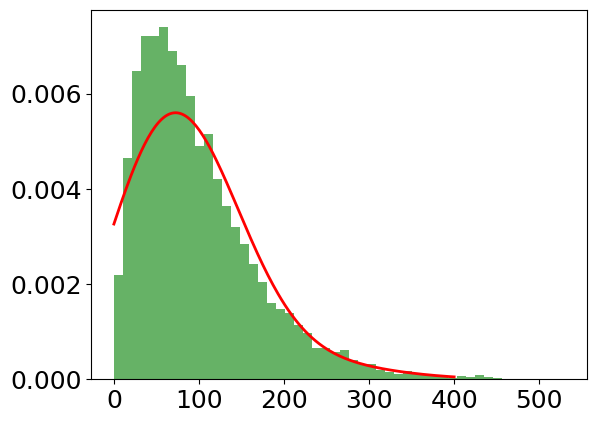

In [37]:
def exponential_pdf_log(x, scale):
    """
    Probability density function of an exponential distribution.
    
    Parameters
    ----------
    x : array_like
        Points at which to evaluate the PDF. Can be scalar or array.
    scale : float or array_like
        The scale parameter (1/λ) of the exponential distribution. Must be > 0.
    
    Returns
    -------
    pdf : array_like
        The PDF values at x.
    """
    # Ensure scale > 0
    scale = jnp.asarray(scale)
    # PDF formula: (1/scale) * exp(–x/scale) for x >= 0, else 0
    pdf = jnp.log(1.0 / scale) + (-x / scale)
    return jnp.where(x >= 0, pdf, -jnp.inf)

def XexpX_pdf_log(x, a):
    """
    Probability density function of the distribution proportional to x * exp(-x/a).
    
    Parameters
    ----------
    x : array_like
        Points at which to evaluate the PDF. Can be scalar or array.
    a : float
        Scale parameter > 0.
    
    Returns
    -------
    pdf : array_like
        The PDF values at x.
    """
    # Ensure a > 0jax.random.PRNGKey(42)
    a = jnp.asarray(a)
    # PDF formula: (1/a^2) * x * exp(-x/a)
    pdf = jnp.log(x) - jnp.log(a**2) - (x / a)
    return jnp.where(x >= 0, pdf, -jnp.inf)

def sample_x_exp(xp, a, size):
    """
    Draw `size` samples from the PDF f(x) ∝ x * exp(-x/a), x>=0.
    
    Parameters
    ----------
    xp : numpy.random.Generator, e.g. np.random.default_rng()
    a  : float, scale parameter > 0
    size : int or tuple, number of samples
    
    Returns
    -------
    samples : array of shape `size`
    """
    # shape=k, scale=theta => Gamma(k, theta)
    return xp.gamma(shape=2.0, scale=a, size=size)

# # Sample 10000 particles
key = np.random.default_rng(1234)
x_exp_x_samples = sample_x_exp(key, 1.0, 10000) * 50.
print(f"Generated {len(x_exp_x_samples)} samples")
print(f"Sample statistics: mean={jnp.mean(x_exp_x_samples):.3f}, std={jnp.std(x_exp_x_samples):.3f}")

H, xedge, _ = plt.hist(x_exp_x_samples, bins=50, density=True, alpha=0.6, color='g')

xmid = 0.5 * (xedge[1:] + xedge[:-1])

v0, s = 50.0, 100
# v0, s = jnp.mean(x_exp_x_samples), jnp.std(x_exp_x_samples)
# h1, h2, h3, h4 = gauss_hermite_coefficients_binned(xmid, H, v0=v0, s=s)
h1, h2, h3, h4 = gauss_hermite_coefficients(x_exp_x_samples, jnp.ones_like(x_exp_x_samples), v0=v0, s=s)
print(f"Gauss-Hermite coefficients: h1={h1:.3f}, h2={h2:.3f}, h3={h3:.3f}, h4={h4:.3f}")
plt.plot(np.linspace(0, 400, 200), reconstruct_gh_distribution(np.linspace(0, 400, 200), v0, s, h1, h2, h3, h4), 'r-', lw=2, label='True PDF')

# # Sample 10000 particles
# key = np.random.default_rng(1234)
# samples = np.random.normal(loc=200.0, scale=50.0, size=10000)
# print(f"Generated {len(samples)} samples")
# print(f"Sample statistics: mean={jnp.mean(samples):.3f}, std={jnp.std(samples):.3f}")

# H, xedge, _ = plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')

# xmid = 0.5 * (xedge[1:] + xedge[:-1])

# v0, s = 150.0, 50.0
# h1, h2, h3, h4 = gauss_hermite_coefficients_binned(xmid, H, v0=v0, s=s)
# print(f"Gauss-Hermite coefficients: h1={h1:.3f}, h2={h2:.3f}, h3={h3:.3f}, h4={h4:.3f}")
# plt.plot(np.linspace(0, 400, 200), reconstruct_gh_distribution(np.linspace(0, 400, 200), v0, s, h1, h2, h3, h4), 'r-', lw=2, label='True PDF')

# Test orbital integration with binning per orbits

In [90]:
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy.integrate import quad
from CylindricalSpline import evaluate_phi_axisymmetric, get_phi_m
from potentials import NFW_potential, NFW_acceleration
from densities import MiyamotoNagai_density
from integrants_with_binning import *

import jax
import jax.numpy as jnp
import jax.scipy as jsp

from time import time

@jax.jit
def getCartesianFromCylindrical_clockwise(R, phi, vR, vphi):
    """
    Reverts R, phi, vR, vphi back to Cartesian x, y, vx, vy.
    Consistent with the 'clockwise' vphi convention provided.
    """
    cos_phi = jnp.cos(phi)
    sin_phi = jnp.sin(phi)
    
    # 1. Positions
    x = R * cos_phi
    y = R * sin_phi
    
    # 2. Velocities
    # Derived by inverting the linear system from your input function
    vx = vR * cos_phi + vphi * sin_phi
    vy = vR * sin_phi - vphi * cos_phi
    
    return x, y, vx, vy

@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    # r = jnp.sqrt(x**2 + y**2 + z**2)
    
    phi_halo = NFW_potential(x, y, z, params_halo)
        # 1. NFW Halo
    # v_c = 200.0 # km/s
    # r_s = 20.0  # kpc
    # phi_halo = - (v_c**2) * jnp.log(1 + r/r_s) / (r/r_s + 1e-5)
    
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val


@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo ):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

# ==========================================
# 3. The Jeans Solver (The Core Logic)
# ==========================================

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output

n_particles =  10_000

print(n_particles)
np.random.seed(42)
with open('./IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T



params_halo_pot = {
    'logM': 11.9,
    'Rs':10 ** 1.3,
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': 9,
    'Rs': 10 ** 0.5,
    'Hs': 10 ** (-0.2),
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 50.0, 1e-3, 20.0, 8.
Nphi = 200
N_int = 10_000
dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
# jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

v_rot, sig_R, sig_z, sig_phi = jeans_moments

key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
vR = g1 * sig_R
vz = g2 * sig_z
vphi = v_rot + g3 * sig_phi

x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
10000


In [91]:
@jax.jit
def acc_fn(x, y, z):
    a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
    a_disk = get_acc(x, y, z, dict_phi)
    return a_halo + a_disk


time =  5. #Gyr
n_steps = 5000
dt = time / n_steps
unroll = False
initial_time = 0.0

In [92]:
time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(w0_new[:5000, :], acc_fn, n_steps, dt, initial_time, unroll)
jax.block_until_ready(xv)

Array([[[-6.16515779e+00,  2.54169989e+00,  4.78864685e-02,
          6.02310715e+01,  1.46840454e+02,  1.99557934e+01],
        [-6.10348988e+00,  2.68794799e+00,  6.78296387e-02,
          6.30903397e+01,  1.45621719e+02,  1.99252586e+01],
        [-6.03897715e+00,  2.83294344e+00,  8.77369940e-02,
          6.59195328e+01,  1.44335342e+02,  1.98841820e+01],
        ...,
        [-3.15650731e-01,  6.95247793e+00, -8.23488712e-01,
          1.51123016e+02,  2.42813511e+01, -6.52773952e+00],
        [-1.64459065e-01,  6.97524738e+00, -8.29826415e-01,
          1.51227280e+02,  2.12579842e+01, -6.14694881e+00],
        [-1.31961638e-02,  6.99499416e+00, -8.35782647e-01,
          1.51265717e+02,  1.82362213e+01, -5.76491165e+00]],

       [[-1.09671583e+01, -1.97548902e+00, -7.42642224e-01,
         -3.84384041e+01,  1.72223969e+02,  2.71598511e+01],
        [-1.10043774e+01, -1.80304539e+00, -7.15396464e-01,
         -3.59962196e+01,  1.72643982e+02,  2.73284588e+01],
        [-1.10391

In [93]:
Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
    (w0_new[:5000, :], acc_fn, n_steps, dt, initial_time, unroll,
    jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-10.,10.],[-10.,10.]]),
    jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
    jnp.zeros(1200), jnp.ones(1200) * 100.0)
jax.block_until_ready(Rzphi_bin_counts)

Array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

In [100]:
h1.shape

(5000, 1200)

/tmp/ipykernel_431780/1440357331.py:12: RuntimeWarning: invalid value encountered in divide
  H_vy = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int)[0] / (H)
/tmp/ipykernel_431780/1440357331.py:13: RuntimeWarning: invalid value encountered in divide
  H_vy2 = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int**2)[0] / (H)
/tmp/ipykernel_431780/1440357331.py:14: RuntimeWarning: invalid value encountered in sqrt
  sigma_vy = np.sqrt(H_vy2 - H_vy**2)
/tmp/ipykernel_431780/1440357331.py:78: RuntimeWarning: invalid value encountered in divide
  H_vy = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int)[0] / (H)
/tmp/ipykernel_431780/1440357331.py:79: RuntimeWarning: invalid value encountered in divide
  H_vy2 = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int**2)[0] / (H)
/tmp/ipykernel_431780/1440357331.py:80: RuntimeWarning: invalid value encountere

Text(0.5, 0.98, 'Gauss-Hermite Coefficients calculated together after integration')

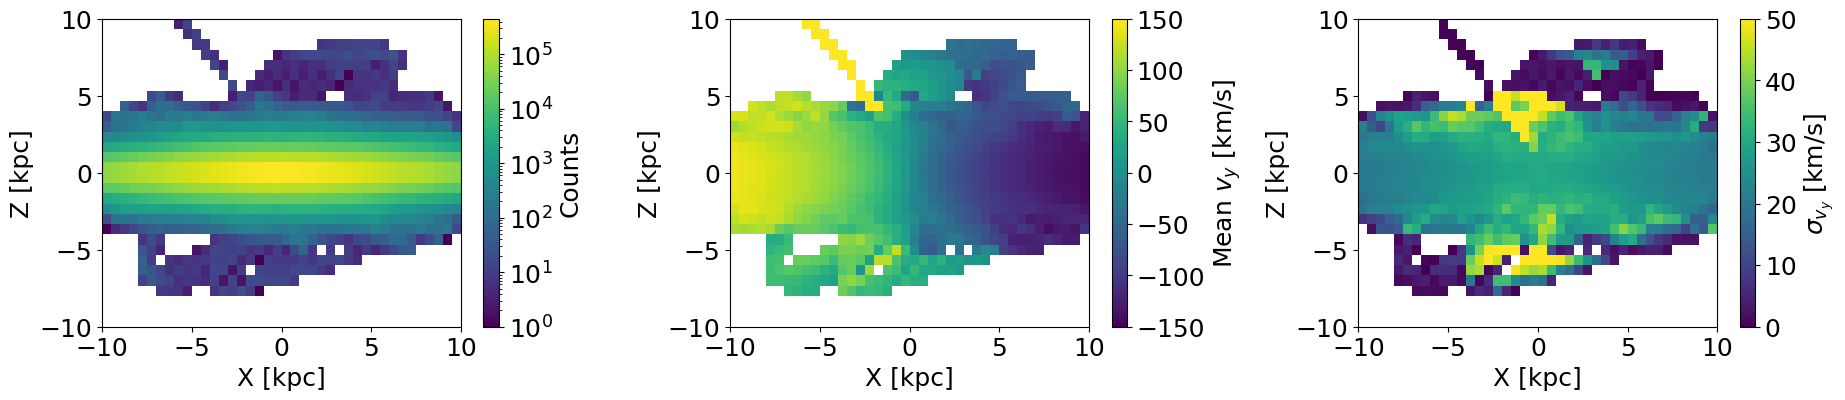

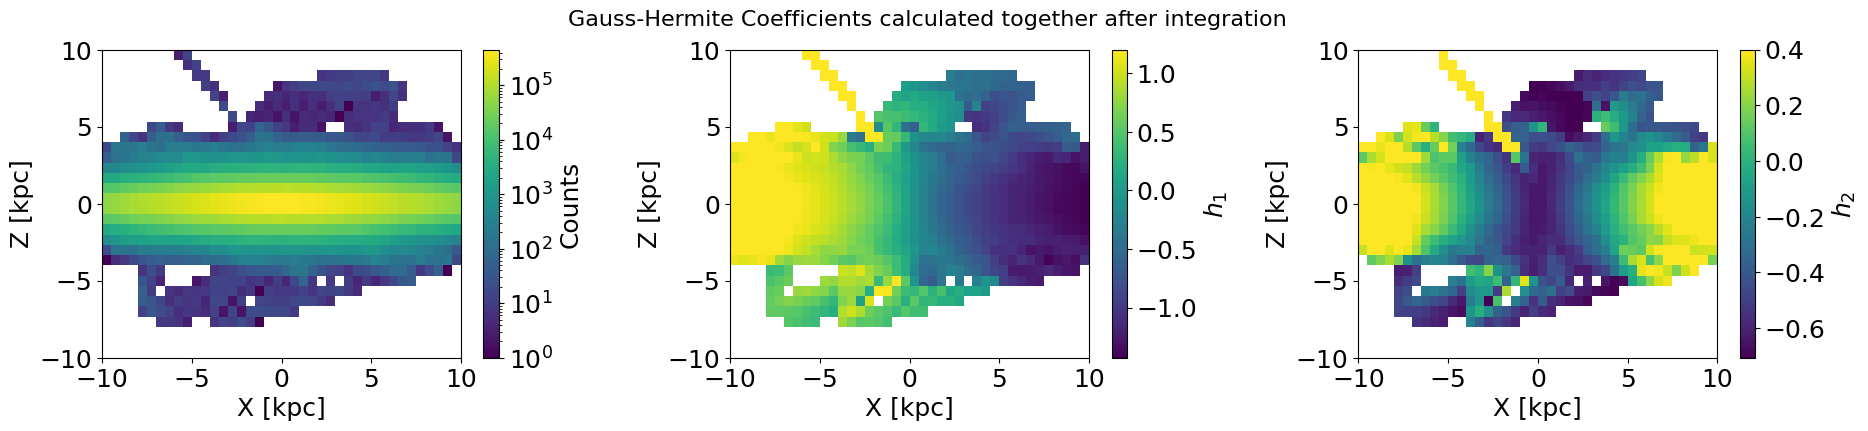

In [96]:
x_int, y_int, z_int, vx_int, vy_int, vz_int = xv[:, :, 0], xv[:, :, 1], xv[:, :, 2], xv[:, :, 3], xv[:, :, 4], xv[:, :, 5]
x_int, y_int, z_int, vx_int, vy_int, vz_int = x_int.flatten(), y_int.flatten(), z_int.flatten(), vx_int.flatten(), vy_int.flatten(), vz_int.flatten()

fig, ax = plt.subplots(1,3, figsize=(22,4), gridspec_kw={'width_ratios':[1,1,1], 'wspace':0.4})

H, xedge, yedge = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]])
cb = ax[0].pcolormesh(xedge, yedge, H.T, shading='auto', norm = mpl.colors.LogNorm())
plt.colorbar(cb, ax=ax[0], label='Counts')
ax[0].set_xlabel('X [kpc]')
ax[0].set_ylabel('Z [kpc]')

H_vy = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int)[0] / (H)
H_vy2 = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int**2)[0] / (H)
sigma_vy = np.sqrt(H_vy2 - H_vy**2)

cb = ax[1].pcolormesh(xedge, yedge, H_vy.T, shading='auto', vmin = -150, vmax=150)
plt.colorbar(cb, ax=ax[1], label='Mean $v_y$ [km/s]')
ax[1].set_xlabel('X [kpc]')
ax[1].set_ylabel('Z [kpc]')

cb = ax[2].pcolormesh(xedge, yedge, sigma_vy.T, shading='auto', vmin = 0, vmax=50)
plt.colorbar(cb, ax=ax[2], label=r'$\sigma_{v_y}$ [km/s]')
ax[2].set_xlabel('X [kpc]')
ax[2].set_ylabel('Z [kpc]')


@jax.jit
def h_to_V_sigma(h1, h2, v0, s):
    """
    Convert h1, h2 to actual mean and sigma of the distribution.
    
    Parameters
    ----------
    h1, h2 : Gauss-Hermite coefficients
    v0 : reference velocity
    s : reference dispersion
    
    Returns
    -------
    v_mean, sigma : actual mean and standard deviation
    """
    v_mean = v0 + s * h1
    sigma = s * jnp.sqrt(jnp.clip(1 + jnp.sqrt(2)*h2 - h1**2, 1e-10))
    
    return v_mean, sigma

@jax.jit
def V_sigma_to_h1h2(V_mean, sigma, v0, s):
    """
    Convert mean and sigma to h1 and h2.
    
    Parameters
    ----------
    V_mean : array or scalar - actual mean velocity
    sigma : array or scalar - actual velocity dispersion
    v0 : array or scalar - reference velocity
    s : array or scalar - reference dispersion
    
    Returns
    -------
    h1, h2 : Gauss-Hermite coefficients
    """
    h1 = (V_mean - v0) / s
    h2 = (sigma**2 / s**2 + h1**2 - 1) / jnp.sqrt(2)
    
    return h1, h2

h1_int, h2_int = V_sigma_to_h1h2(H_vy, sigma_vy, v0=0.0, s=100.0)

fig, ax = plt.subplots(1,3, figsize=(22,4), gridspec_kw={'width_ratios':[1,1,1], 'wspace':0.4})

H, xedge, yedge = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]])
cb = ax[0].pcolormesh(xedge, yedge, H.T, shading='auto', norm = mpl.colors.LogNorm())
plt.colorbar(cb, ax=ax[0], label='Counts')
ax[0].set_xlabel('X [kpc]')
ax[0].set_ylabel('Z [kpc]')

H_vy = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int)[0] / (H)
H_vy2 = np.histogram2d(x_int, z_int, bins=(40,30), range=[[-10,10],[-10,10]], weights=vy_int**2)[0] / (H)
sigma_vy = np.sqrt(H_vy2 - H_vy**2)

cb = ax[1].pcolormesh(xedge, yedge, h1_int.T, shading='auto', vmax = 1.2)
plt.colorbar(cb, ax=ax[1], label='$h_1$')
ax[1].set_xlabel('X [kpc]')
ax[1].set_ylabel('Z [kpc]')

cb = ax[2].pcolormesh(xedge, yedge, h2_int.T, shading='auto', vmax = 0.4)
plt.colorbar(cb, ax=ax[2], label='$h_2$')
ax[2].set_xlabel('X [kpc]')
ax[2].set_ylabel('Z [kpc]')

fig.suptitle('Gauss-Hermite Coefficients calculated together after integration', fontsize=16)

Text(0.5, 0.98, 'Gauss-Hermite Coefficients calculated per orbits and summed after integration')

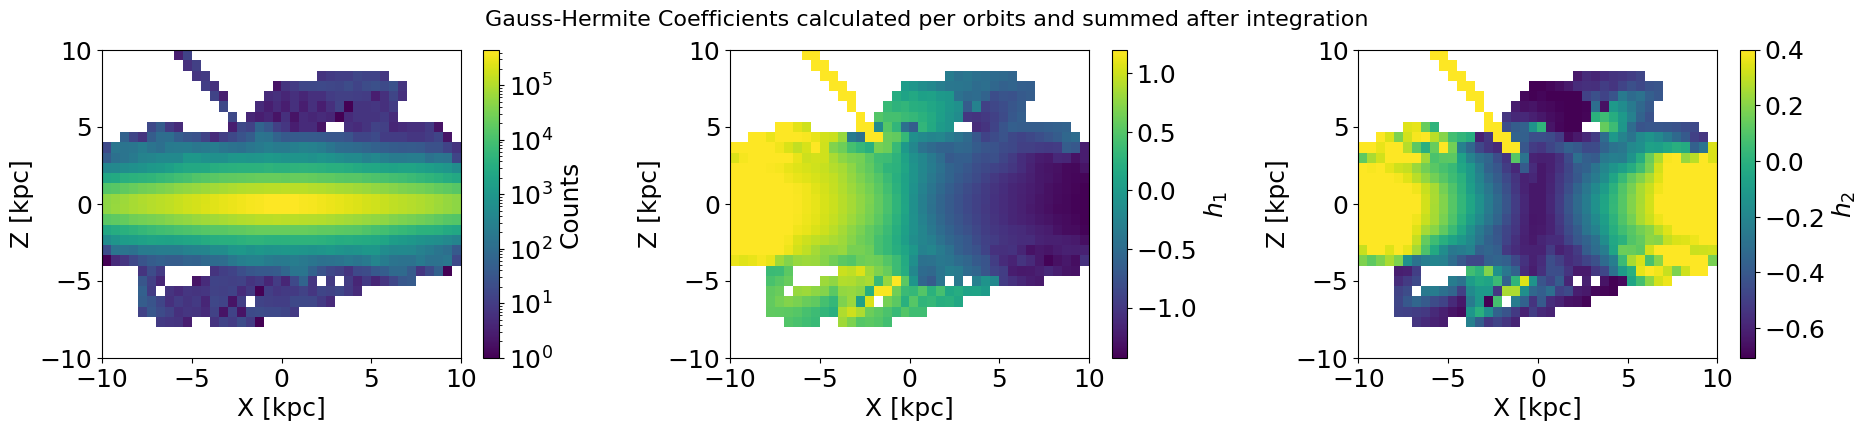

In [97]:
Nxy_sum, h1_sum, h2_sum, h3_sum, h4_sum = jnp.sum(Nxy, axis=0), jnp.sum(h1*Nxy, axis=0), jnp.sum(h2*Nxy, axis=0), jnp.sum(h3*Nxy, axis=0), jnp.sum(h4*Nxy, axis=0)
Nxy_reshape, h1_reshape, h2_reshape, h3_reshape, h4_reshape = Nxy_sum.reshape(30,40), h1_sum.reshape(30,40), h2_sum.reshape(30,40), h3_sum.reshape(30,40), h4_sum.reshape(30,40)
h1_reshape = h1_reshape / Nxy_reshape
h2_reshape = h2_reshape / Nxy_reshape
h3_reshape = h3_reshape / Nxy_reshape
h4_reshape = h4_reshape / Nxy_reshape

fig, ax = plt.subplots(1,3, figsize=(22,4), gridspec_kw={'width_ratios':[1,1,1], 'wspace':0.4})
cb = ax[0].imshow(Nxy_reshape, origin='lower', extent=(-10,10,-10,10), aspect='auto', norm = mpl.colors.LogNorm())
plt.colorbar(cb, ax=ax[0], label='Counts')
ax[0].set_xlabel('X [kpc]')
ax[0].set_ylabel('Z [kpc]')

cb = ax[1].imshow(h1_reshape, origin='lower', extent=(-10,10,-10,10), aspect='auto', vmax = 1.2)
plt.colorbar(cb, ax=ax[1], label='$h_1$')
ax[1].set_xlabel('X [kpc]')
ax[1].set_ylabel('Z [kpc]')

cb = ax[2].imshow(h2_reshape, origin='lower', extent=(-10,10,-10,10), aspect='auto', vmax = 0.4)
plt.colorbar(cb, ax=ax[2], label='$h_2$')
ax[2].set_xlabel('X [kpc]')
ax[2].set_ylabel('Z [kpc]')

fig.suptitle('Gauss-Hermite Coefficients calculated per orbits and summed after integration', fontsize=16)